# Week 8 - Correlation analysis and the water content of the Earth's mantle

## Understanding Correlation, Pearson's r, t-test, and p-values

### Correlation
Correlation measures the strength and direction of a linear relationship between two variables. The correlation coefficient quantifies this relationship.

#### Key Points:
- Correlation values range from **-1** to **1**.
- A value near **1** indicates a strong positive correlation.
- A value near **-1** indicates a strong negative correlation.
- A value near **0** indicates no correlation.

### Pearson's r
Pearson's correlation coefficient (**r**) is a common measure of linear correlation.

#### Formula:
$$ r = \frac{\sum (x_i - \overline{x})(y_i - \overline{y})}{\sqrt{\sum (x_i - \overline{x})^2 \sum (y_i - \overline{y})^2}} $$

#### Interpretation:
- **r > 0**: Positive correlation
- **r < 0**: Negative correlation
- **|r| ≈ 1**: Strong correlation

#### Assumptions:
- Both variables are continuous and approximately normally distributed.
- The relationship is linear.
- Data points are independent.

### t-test for Pearson's r
The **t-test** helps determine if the observed correlation is statistically significant.

#### t-statistic formula:
$$ t = r \sqrt{\frac{n - 2}{1 - r^2}} $$

Where:
- **r** = Pearson correlation coefficient
- **n** = Number of data points

### p-value
The **p-value** quantifies the probability that the observed correlation occurred by chance under the null hypothesis (no correlation).

#### Key Points:
- A **small p-value** (e.g., **p < 0.05**) indicates strong evidence to reject the null hypothesis.
- A **large p-value** (e.g., **p > 0.05**) suggests insufficient evidence to conclude a significant correlation.

### Example Workflow
1. Visualize data using a scatterplot.
2. Compute Pearson's **r**.
3. Perform a t-test and obtain the p-value.
4. Interpret the correlation strength and significance.

### Python Code Example


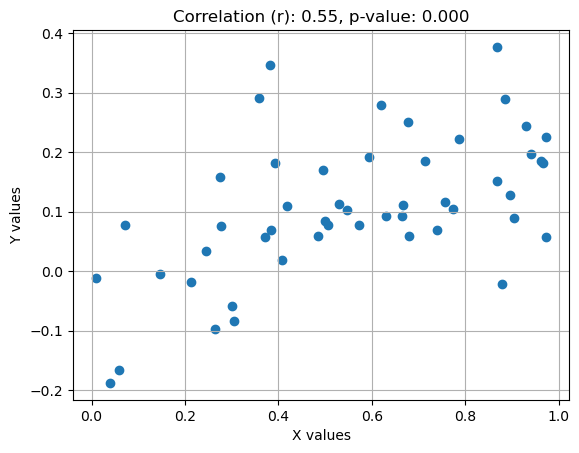

In [78]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Example data
x = np.random.rand(50)
y = 0.2 * x + np.random.normal(0, 0.1, 50)

# Pearson's r and p-value
r, p_value = stats.pearsonr(x, y)

# Plotting
def plot_data(x, y, r, p_value):
    plt.scatter(x, y)
    plt.title(f'Correlation (r): {r:.2f}, p-value: {p_value:.3f}')
    plt.xlabel('X values')
    plt.ylabel('Y values')
    plt.grid(True)
    plt.show()

plot_data(x, y, r, p_value)

## Exercise 1 - load global mid-ocean ridge data and plot sample location - remember what we learned in the cartopy lesson!

**(10 points)** Import the following dataset, this is a compilation of geochemical data collected from mid-ocean ridge basalts around the world. Before we go any further, **let's plot up the data on a map using cartopy to check that these samples are from the locations that we'd expect**. If you're unsure what that means look back to the second map on homework 1: where the age of the crust is 0 represents regions of active volcanism, so it's in these regions that we expect to find the samples in the dataset.

In [79]:
import pandas as pd
import cartopy.crs as ccrs

In [80]:
morb = pd.read_excel('data/earthchem_MORB.xlsx')
morb.head()

,SAMPLE ID,IGSN,EXPEDITION ID,REFERENCES,LATITUDE,LONGITUDE,LOC PREC,MIN ELEVATION,MAX ELEVATION,TECTONIC SETTING,...,EU,GD,TB,DY,HO,ER,TM,YB,LU,CO2
0,POLAN15-2-099-001,NaN,POLAN15-2,"FRETZDORFF, 2002",-57.600,-30.4900,1.000000e-02,-3688.0,-3688.0,SPREADING_CENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FBPRCA1-DI-18,NaN,nr,"ALVAREZ-VALERO, 2020",-62.966,-60.7136,1.000000e-06,NaN,NaN,SPREADING_CENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CROHPOCA3-DIPV37-F,NaN,nr,"ALVAREZ-VALERO, 2020",-62.936,-60.6945,1.000000e-06,NaN,NaN,SPREADING_CENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,JS20266-054,NaN,JS20266,"WANLESS, 2011",9.148,-104.1980,1.000000e-08,-2547.0,-2547.0,SPREADING_CENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KLM0417-R119,NaN,KIL0417,"BEZOS, 2009",-20.018,-176.1140,1.000000e-03,-2609.0,-2609.0,SPREADING_CENTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


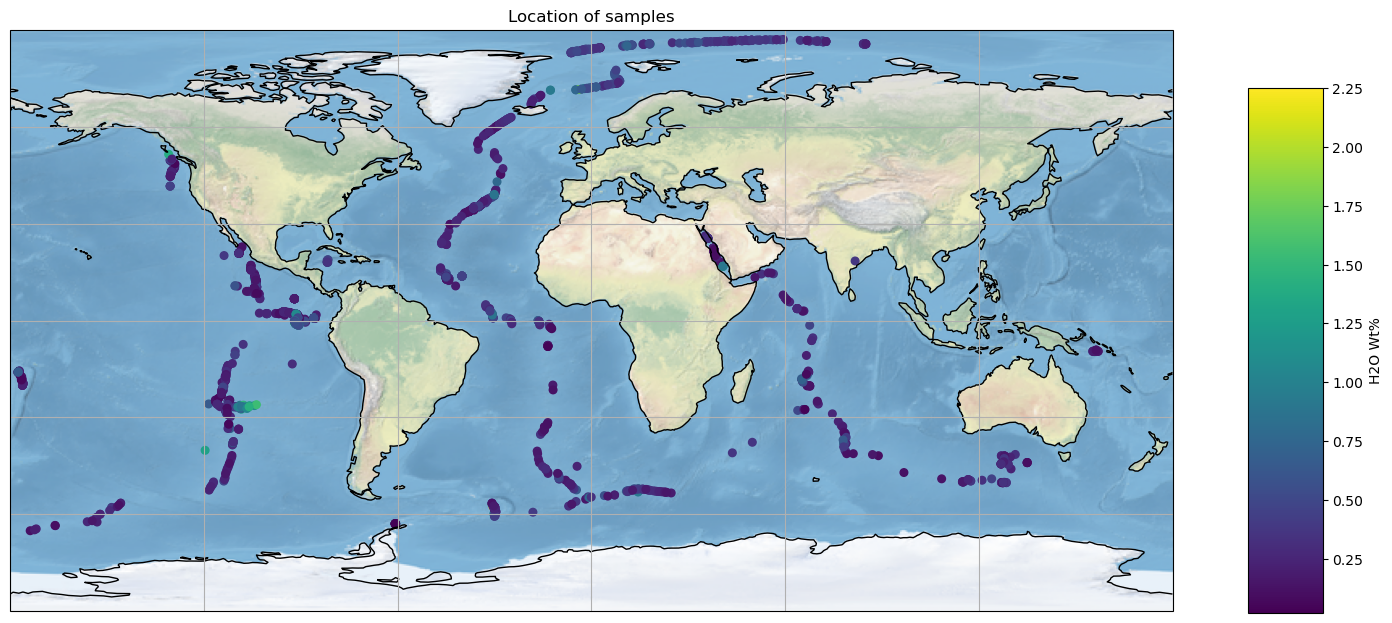

In [102]:


## extract longitude, latitude
lat = morb['LATITUDE']
logn = morb['LONGITUDE']
c = morb['H2O']

## Make a figure
plt.figure(figsize=(15,15))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()


data= ax.scatter(logn, lat, s=30, marker='o', c = morb['H2O'],  transform=ccrs.PlateCarree())

ax.coastlines(), ax.stock_img(), ax.gridlines()
plt.title('Location of samples')    

color_ax = plt.axes([0.95, 0.3, 0.05, 0.35])
plt.colorbar(data, cax= color_ax, label= 'H2O Wt%')


# or c = 'red' for the scatterplot, was unsure what was aked for


## Exercise 2 - finding correlations

One of the hardest, yet most important parameters to constrain in volcanic rocks is the water content of the magma before eruption. Water is challenging (and expensive) to measure so water analyses arn't done regularly. 

**(5 points)** Check this, in the dataset you just imported. What proportion of analyses have reported H2O contents?

In [82]:
H2O = morb['H2O']
H2O_cont = H2O.dropna().shape[0]
samp  = len(morb)

prop = ((H2O_cont/samp)*100)
print(f'The proportion of analyses having reported H2O contents are {prop:.2f} %')

The proportion of analyses having reported H2O contents are 9.46 %


### The Importance of Constraining Water in Magmas

Water plays a crucial role in the physical and chemical behavior of magmas, significantly influencing volcanic explosivity, magma buoyancy, and rheology. Understanding water content is essential for interpreting volcanic processes and mantle dynamics.

1. Influence on Magma Explosivity

Water dissolved in magma remains stable at high pressures but begins to exsolve (separate into gas bubbles) as pressure decreases during magma ascent. This rapid exsolution generates gas bubbles that expand, driving explosive eruptions. The higher the water content in the magma, the greater the potential for volatile overpressure and fragmentation, resulting in more violent eruptions.

![Schematic of eruptive processes](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41467-018-05293-3/MediaObjects/41467_2018_5293_Fig1_HTML.png)

2. Exsolution, Buoyancy, and Rheology

Water exsolution not only drives explosive behavior but also modifies magma density and viscosity. As water exsolves, the expanding bubbles reduce magma density, increasing its buoyancy and promoting faster ascent. Simultaneously, water reduces the viscosity of silicate melts, enhancing magma mobility. However, once bubbles begin to form, the presence of a gas phase can increase magma's effective viscosity, depending on bubble size, shape, and distribution.

3. Influence on Mantle Rheology

Water content in the mantle profoundly affects its rheological properties. Even trace amounts of water weaken silicate minerals by enhancing defect mobility, facilitating ductile deformation. This reduction in viscosity enables mantle convection, influencing large-scale tectonic processes such as plate motion and lithospheric thinning. Variations in mantle hydration are thus critical for understanding mantle dynamics and magmatic behavior at depth.

By carefully constraining water content in magmatic systems and the mantle, researchers can better predict volcanic hazards, understand melt generation processes, and model mantle flow dynamics.

In the remaining parts of this notebook we're going to identify correlations between the water content of mid-ocean ridge basalts and other, easier to measure parameters. One potential option is to look at trace elements such as La, Ce, and Nd. According to experiments these elements should act similarly to H2O during mantle melting and magma differentiation until the point H2O gas bubbles start to form.

**(10 points)** In the cell below I show you how we can use seaborn to create a 'correlation matrix'. This shows the correlation between every pair of variables in a dataframe. Using the spare cell below create a second correlation matrix, filtering the dataframe to ONLY include the MgO, H2O, CO2, La, Ce, Nd, Sm, Er, and Yb contents of these samples. In your plot try setting ```annot = True```, what values do you think this is displaying?

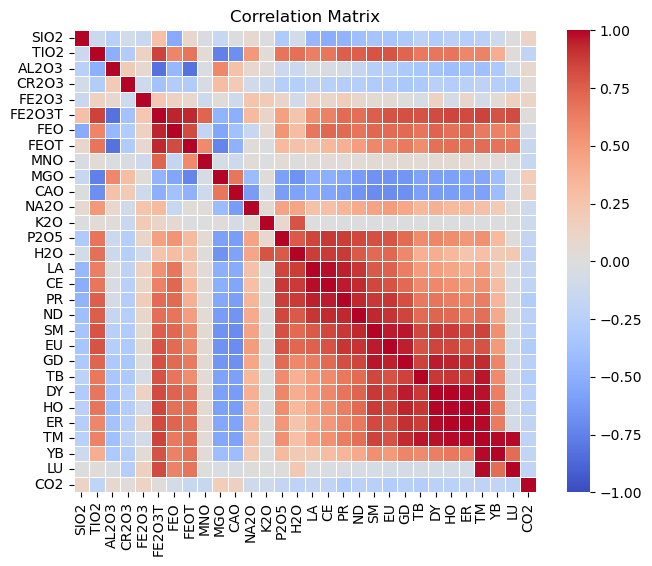

In [83]:
import seaborn as sns

# I'm going to first filter the data to remove columns with string variables - this isn't neccessary below
m = morb.loc[:, 'SIO2':].copy()

# Compute correlation matrix
corr_matrix = m.corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            cbar=True, square=True, linewidths=0.5)

plt.title('Correlation Matrix')
plt.show()


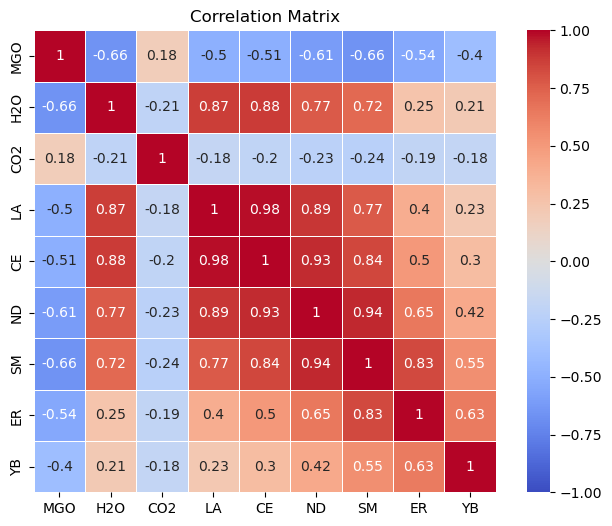

In [84]:

m = morb.loc[:,['MGO', 'H2O', 'CO2', 'LA', 'CE', 'ND', 'SM', 'ER','YB']].copy()

# Compute correlation matrix
corr_matrix = m.corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            cbar=True, square=True, linewidths=0.5)

plt.title('Correlation Matrix')
plt.show() 


I think that the values shown is the correlation of each valu intersecting. Seeing the higest number value for the cells where the same minerals meets 

## Exercise 3 - which correlations are statistically significant?

**(5 points)** Let's look at the correlations between H2O and La and between H2O and Yb. Plot up two scatter plots showing these data (use subplots). Just as a note, the H2O contents are reported in wt% and the La and Yb contents are reported in ppm.

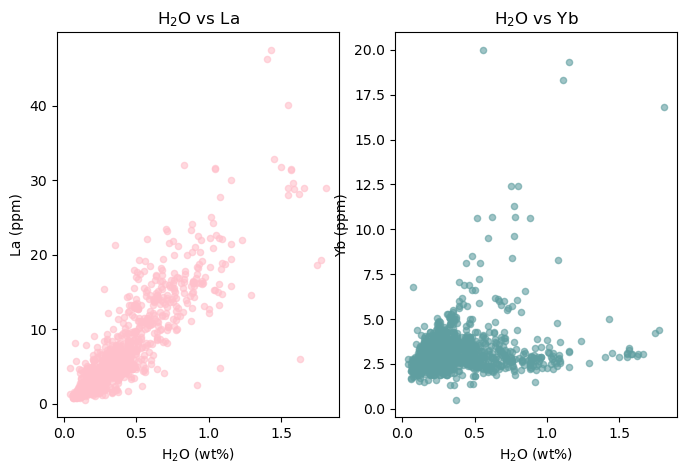

In [108]:
filt = morb[['H2O', 'LA', 'YB']].dropna()
f, ax =  plt.subplots(1,2, figsize = (8,5), sharex=True)
ax[0].scatter(filt['H2O'], filt['LA'], s= 20, marker = 'o', alpha = 0.6, color= 'pink')
ax[0].set_xlabel('H$_2$O (wt%)')
ax[0].set_ylabel('La (ppm)')
ax[0].set_title('H$_2$O vs La')

ax[1].scatter(filt['H2O'], filt['YB'], s= 20, marker = 'o', alpha = 0.6, color= 'cadetblue')
ax[1].set_xlabel('H$_2$O (wt%)')
ax[1].set_ylabel('Yb (ppm)')
ax[1].set_title('H$_2$O vs Yb')
plt.show()

**(10 points)** use the scipy.stats submodule to calculate the pearson r value and p-value for the plots shown above (i.e., r, and p value for H2O vs La and H2O vs Yb). Use the ```pearsonr``` function to do this. One thing you'll have to do is further filter the dataframe to remove rows where either variable is ```nan```.

In [86]:
from scipy.stats import pearsonr
help(pearsonr)

Help on function pearsonr in module scipy.stats._stats_py:

pearsonr(x, y, *, alternative='two-sided', method=None, axis=0)
    Pearson correlation coefficient and p-value for testing non-correlation.

    The Pearson correlation coefficient [1]_ measures the linear relationship
    between two datasets. Like other correlation
    coefficients, this one varies between -1 and +1 with 0 implying no
    correlation. Correlations of -1 or +1 imply an exact linear relationship.
    Positive correlations imply that as x increases, so does y. Negative
    correlations imply that as x increases, y decreases.

    This function also performs a test of the null hypothesis that the
    distributions underlying the samples are uncorrelated and normally
    distributed. (See Kowalski [3]_
    for a discussion of the effects of non-normality of the input on the
    distribution of the correlation coefficient.)
    The p-value roughly indicates the probability of an uncorrelated system
    producing 

In [110]:
value1 = pearsonr(filt['H2O'], filt['LA']) 
print(f'Pearson R:{value1.statistic:24f}')
print(f'P-value: {value1.pvalue:.2f}')

Pearson R:                0.870681
P-value: 0.00


In [111]:
value2 = pearsonr(filt['H2O'], filt['YB'])
print(f'Pearson R:{value2.statistic:24f}')
print(f'P-value: {value2.pvalue:.2f}')

Pearson R:                0.213362
P-value: 0.00


## Exercise 4 - What is the water content of the mantle

What we often do, when trying to estimate magma or mantle water contents, is take the measured content of a trace element that correlates strongly with H2O and then use the ratio between H2O and the selected trace element to estimate the H2O content of all other samples.

Here we're going to use the available data to try and estimate how much water is stored in the Earth's mantle. This is important as the H2O content of the mantle influences several things, such as the extent of melting in volcanic regions and the viscosity of the solid mantle (resistance to flow). 

It's also really important for trying to constrain the origin scenarios of the Earth. For example, one important question is whether the Earth must have been constructed (at least in part) by comets, or if there is enough water in chondritic meteorites to generate our 'water planet'.

![Origin of Earth's water](https://www.lpi.usra.edu/planetary_news/wp-content/uploads/2020/08/Sources-of-Earths-Water.jpg)

**(5 points)** Create another plot of H2O vs La, then plot H2O/La (y-axis) vs La (x-axis) and add horizontal lines indicating the mean H2O/La value in addition to the 16th and 84th percentile. Adjust the y limits so we can actually see the medians and percentiles. 

When calculating the H2O/La ratio multiple the H2O content by 10000. This will convert the wt% values into ppm (so that the two variables are the same unit).

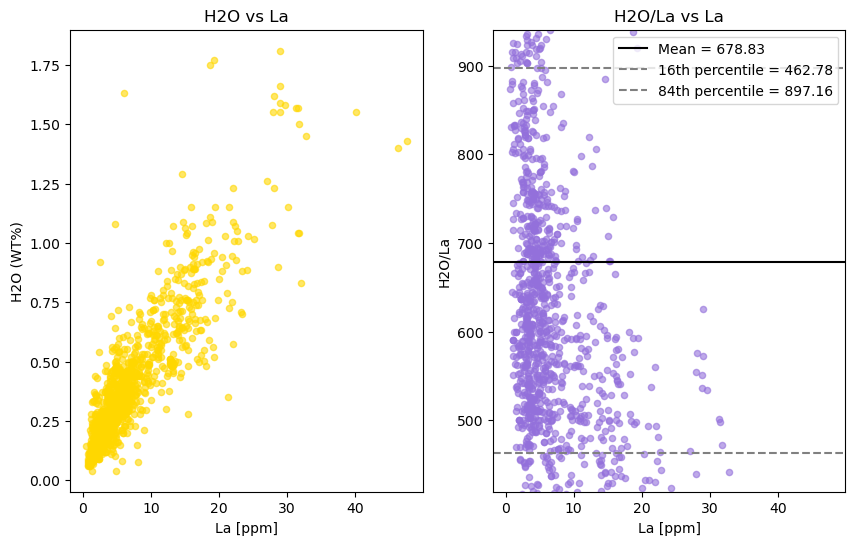

In [112]:
filt = morb[['H2O', 'LA']].dropna().copy()

filt['H2O_LA'] = filt['H2O']*10000 / filt['LA']

mean= filt['H2O_LA'].mean()
pre16 = filt['H2O_LA'].quantile(0.16)
pre84 = filt['H2O_LA'].quantile(0.84)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))


ax[0].scatter(filt['LA'], filt['H2O'], s=20, alpha=0.6, color='gold')
ax[0].set_xlabel('La [ppm]')
ax[0].set_ylabel('H2O (WT%)')
ax[0].set_title('H2O vs La')

ax[1].scatter(filt['LA'], filt['H2O_LA'], s=20, alpha=0.6, color='mediumpurple')
ax[1].axhline(mean, color='black', linestyle='-', label=f'Mean = {mean:.2f}')
ax[1].axhline(pre16, color='gray', linestyle='--', label=f'16th percentile = {pre16:.2f}')
ax[1].axhline(pre84, color='gray', linestyle='--', label=f'84th percentile = {pre84:.2f}')

ax[1].set_xlabel('La [ppm]')
ax[1].set_ylabel('H2O/La')
ax[1].set_title('H2O/La vs La')

ax[1].set_ylim(pre16 - 0.1*(pre84-pre16), pre84 + 0.1*(pre84-pre16))

ax[1].legend()

plt.show()

**(5 points)** We assume that the ratio of H2O/La measured in a mid-ocean ridge basalt is the same as the ratio of these two elements in the Earth's mantle. The average La content of the Earth's mantle is 0.687 ppm. What is the H2O content of the Earth's mantle? Use the median H2O/La value determined above.

In [113]:
median_ratio= filt['H2O_LA'].median()
mantle_H2Oppm = median_ratio * 0.687
print(f'the H2O content of the mantel is {mantle_H2Oppm:.2f}')

the H2O content of the mantel is 419.83


**(10 points)** Assume the mantle has a density of 3300 kg/m$^3$. The water content of the mantle estimated above is in parts per million by mass. How many kilograms of water are contained in the Earth's mantle?

Assume the core has a radius of 3485 km and the mantle + core has a total radius of 6350 km.

In [114]:
r_mantle = 6350000
r_core = 3485000
dens = 3300 #kg/m^3

                                                                        
vol = (4/3)* np.pi * (r_mantle**3-r_core**3)

mass_e = vol* dens
mass_w = mass_e*mantle_H2Oppm* 1e-6

print(f'{mass_w:.2e} kilograms of water are contained in the Earths mantle')



1.24e+21 kilograms of water are contained in the Earths mantle


**(5 points)** The Earth's oceans contain approximately $1.4\times 10^{21}$ kg of H2O. How What proportion of the Earth's water is contained within the mantle (assume there is negligible amounts in the crust or core).

In [92]:
proportion_m_o = mass_w / (mass_w + 1.4e21)
proportion_m_o = proportion_m_o *100

print(f'{proportion_m_o:.2f}% of Earths water is contained within the mantle')

46.98% of Earths water is contained within the mantle


**One of the unique characteristics of our planet (compared to others in the solar system) is the presence of liquid water at the surface. Do some independent reseaerch. Why might the presence of abundant water in/on our planet be important for: (i) the origin of life; and (ii) the origin of plate tectonics.**

(10 points)

(i)
    The presence of water is important for the origin of life because it creates oceans and drives geodynamic cycles. H2O is to exist in nearly any cehmical reaction. It is essential for life because it acts as a universal solvent, allowing organic molecules and ions to dissolve and react. Hydrothermal vents are a big factor for life origin, providing chemical gradients, mineral catalysts, and thermal stability.
    The oceans are a big contributor to the ocean- current systems that control weather and climate. Processes like upwelling, where cold deep water rises to the surface, bring nutrients upward, creating environments that are nutrition rich.

(ii)
    The presence of water, particularly as a volatile component, plays a big role in plate tectonics. Water promotes flux melting, which lowers the melting temperature of mantle rocks and enables partial melting under conditions where dry rocks would remain solid. This is essential for magma generation at subduction zones.
    In addition, water drives weathering and erosion at the surface, which helps weaken rocks. Seawater infiltrates oceanic crust which reduces the strength of materials within the lithosphere. It nakes the rock more hydrated, enhancing fracturing and ductile deformation, and making it easier for tectonic plates to move and deform.

  The presence of abundant water therefore plays a key role both for life and for tectonic processes, acting as a biological enabler and a kind of lubricant for plate motion. This makes Earth uniquely suited to support life and maintain active plate motion compared to the other terrestrial planets in our solar system. 

# Extra Credit - add another 10% to your grade in this assignment.

Using a Monte Carlo approach propagate the uncertainties in the H2O/La ratio through the calculations used to estimate the proportion of the Earth's H2O contained in the Earth's mantle.

Plot (as a histogram) the posterior distribution for the proportion of Earth's water that is contained in the mantle.

In [ ]:
np.random.seed(42)
N = 10000


ratios = filt['H2O_LA'].values

La_cont   = 0.687
rho      = 3300
r_mantle = 6_350_000
r_core   = 3_485_000
M_ocean  = 1.4e21

V_mantle = (4/3) * np.pi * (r_mantle**3 - r_core**3)
M_mantle = rho * V_mantle

In [94]:
f_samples = np.empty(N)
for i in range(N):
    r_boot      = np.median(np.random.choice(ratios, size=len(ratios), replace=True))
    H2O_wt      = r_boot * La_cont           
    M_H2O_i     = (H2O_wt / 100) * M_mantle 
    f_samples[i] = M_H2O_i / M_ocean

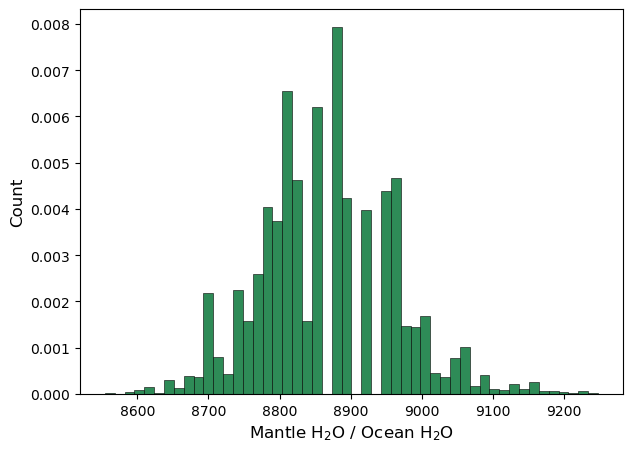

In [98]:
plt.figure(figsize=(7, 5))
plt.hist(f_samples, bins=50, color='seagreen', edgecolor='k', linewidth=0.4, density=True)
plt.xlabel('Mantle H$_2$O / Ocean H$_2$O', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()
plt.show()